In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

def residualize(y, X):
    reg = LinearRegression().fit(X, y)
    return y - reg.predict(X)

In [2]:
patientsData = pd.read_csv('DATResults.csv')

In [3]:

df = patientsData[ ['PatientID', 'Contralateral_Caudate_Z', 'Ipsilateral_Caudate_Z', 'Final_Score', 'Age','Side'] ].dropna().copy() 
var = 'Final_Score'

# Fit the model
model = smf.mixedlm(
    formula=f"Q('{var}') ~ Contralateral_Caudate_Z + Age + C(Side)",
    data=df,
    groups=df["PatientID"],
    re_formula='~1'
)

result = model.fit(reml=True)
print(result.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Q('Final_Score')
No. Observations:   54       Method:              REML            
No. Groups:         31       Scale:               5.8386          
Min. group size:    1        Log-Likelihood:      -131.3172       
Max. group size:    2        Converged:           Yes             
Mean group size:    1.7                                           
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               -2.610    1.978 -1.320 0.187 -6.486  1.267
C(Side)[T.Right]         0.429    0.677  0.634 0.526 -0.897  1.755
Contralateral_Caudate_Z -0.604    0.252 -2.392 0.017 -1.098 -0.109
Age                      0.070    0.029  2.431 0.015  0.014  0.126
Group Var                1.761    0.964                           



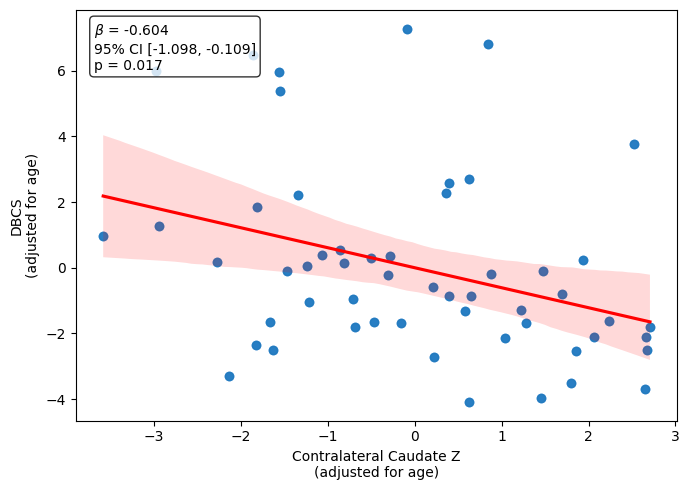

In [6]:
var = 'Final_Score'

age = df[["Age"]].values
brain_res =residualize(df["Contralateral_Caudate_Z"].values, age)
kinematic_res = residualize(df["Final_Score"].values, age)


beta = result.params['Contralateral_Caudate_Z'] 
p = result.pvalues['Contralateral_Caudate_Z'] 
ci = result.conf_int().loc['Contralateral_Caudate_Z'].values 

# Step 2 — regression line from your LMM beta
x_line = np.linspace(brain_res.min(), brain_res.max(), 100)
y_line = beta * x_line  # your beta

# Step 3 — plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(brain_res, kinematic_res, alpha=1, color="#378ADD", label="Observations")
# ax.plot(x_line, y_line, color="#D85A30", linewidth=2, label=f"β = {beta:.2f}\np = {p:.3f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]")
# ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
# ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

sns.regplot(x=brain_res, y=kinematic_res, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=ax)

ax.set_xlabel("Contralateral Caudate Z\n(adjusted for age)")
ax.set_ylabel("DBCS\n(adjusted for age)")
ax.text( 0.03, 0.97, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]\n" f"p = {p:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

# ax.legend()
plt.tight_layout()
plt.show()

In [7]:
df = patientsData[ ['PatientID', 'Contralateral_Putamen_Z', 'Ipsilateral_Putamen_Z', 'Final_Score', 'Age','Side'] ].dropna().copy() 
var = 'Final_Score'

# Fit the model
model = smf.mixedlm(
    formula=f"Q('{var}') ~ Contralateral_Putamen_Z + Age + C(Side)",
    data=df,
    groups=df["PatientID"],
    re_formula='~1'
)

result = model.fit(reml=True)
print(result.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  Q('Final_Score')
No. Observations:   54       Method:              REML            
No. Groups:         31       Scale:               5.9458          
Min. group size:    1        Log-Likelihood:      -132.4522       
Max. group size:    2        Converged:           Yes             
Mean group size:    1.7                                           
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               -2.949    2.216 -1.331 0.183 -7.293  1.395
C(Side)[T.Right]         0.522    0.681  0.767 0.443 -0.813  1.857
Contralateral_Putamen_Z -0.433    0.234 -1.853 0.064 -0.890  0.025
Age                      0.076    0.031  2.486 0.013  0.016  0.136
Group Var                2.015    0.976                           



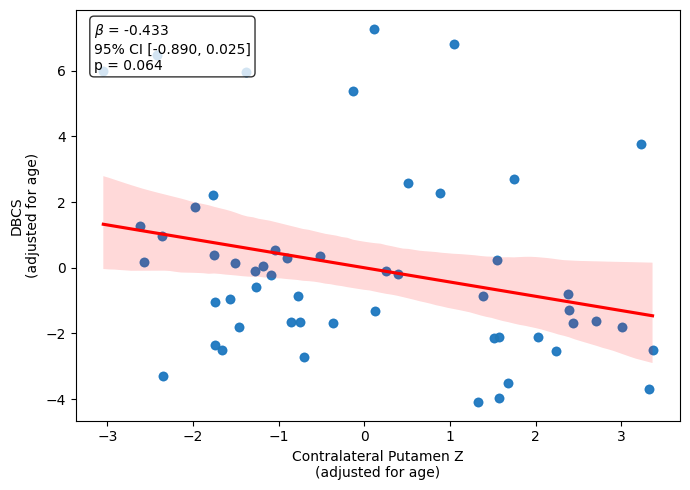

In [8]:
var = 'Final_Score'

age = df[["Age"]].values
brain_res =residualize(df["Contralateral_Putamen_Z"].values, age)
kinematic_res = residualize(df["Final_Score"].values, age)


beta = result.params['Contralateral_Putamen_Z'] 
p = result.pvalues['Contralateral_Putamen_Z'] 
ci = result.conf_int().loc['Contralateral_Putamen_Z'].values 

# Step 2 — regression line from your LMM beta
x_line = np.linspace(brain_res.min(), brain_res.max(), 100)
y_line = beta * x_line  # your beta

# Step 3 — plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(brain_res, kinematic_res, alpha=1, color="#378ADD", label="Observations")
# ax.plot(x_line, y_line, color="#D85A30", linewidth=2, label=f"β = {beta:.2f}\np = {p:.3f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]")
# ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
# ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

sns.regplot(x=brain_res, y=kinematic_res, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=ax)

ax.set_xlabel("Contralateral Putamen Z\n(adjusted for age)")
ax.set_ylabel("DBCS\n(adjusted for age)")
ax.text( 0.03, 0.97, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]\n" f"p = {p:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

# ax.legend()
plt.tight_layout()
plt.show()

In [9]:
df = patientsData[ ['PatientID', 'Contralateral_Striatum_Z', 'Ipsilateral_Striatum_Z', 'Final_Score', 'Age','Side'] ].dropna().copy() 
var = 'Final_Score'

# Fit the model
model = smf.mixedlm(
    formula=f"Q('{var}') ~ Contralateral_Striatum_Z + Age + C(Side)",
    data=df,
    groups=df["PatientID"],
    re_formula='~1'
)

result = model.fit(reml=True)
print(result.summary())

               Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  Q('Final_Score')
No. Observations:    54       Method:              REML            
No. Groups:          31       Scale:               5.9155          
Min. group size:     1        Log-Likelihood:      -132.1223       
Max. group size:     2        Converged:           Yes             
Mean group size:     1.7                                           
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -2.933    2.146 -1.367 0.172 -7.138  1.273
C(Side)[T.Right]          0.500    0.680  0.735 0.462 -0.832  1.832
Contralateral_Striatum_Z -0.480    0.237 -2.026 0.043 -0.945 -0.016
Age                       0.075    0.030  2.501 0.012  0.016  0.134
Group Var                 1.935    0.975                       

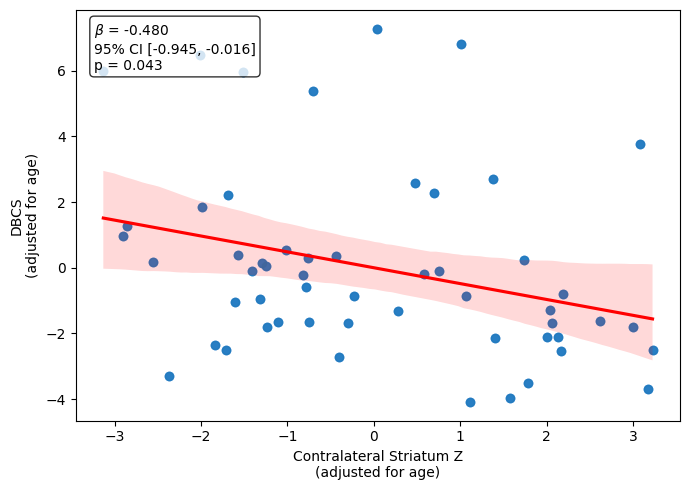

In [10]:
var = 'Final_Score'

age = df[["Age"]].values
brain_res =residualize(df["Contralateral_Striatum_Z"].values, age)
kinematic_res = residualize(df["Final_Score"].values, age)


beta = result.params['Contralateral_Striatum_Z'] 
p = result.pvalues['Contralateral_Striatum_Z'] 
ci = result.conf_int().loc['Contralateral_Striatum_Z'].values 

# Step 2 — regression line from your LMM beta
x_line = np.linspace(brain_res.min(), brain_res.max(), 100)
y_line = beta * x_line  # your beta

# Step 3 — plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(brain_res, kinematic_res, alpha=1, color="#378ADD", label="Observations")
# ax.plot(x_line, y_line, color="#D85A30", linewidth=2, label=f"β = {beta:.2f}\np = {p:.3f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]")
# ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
# ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

sns.regplot(x=brain_res, y=kinematic_res, scatter_kws={'alpha': 0.6}, line_kws={'color': 'red'}, ax=ax)

ax.set_xlabel("Contralateral Striatum Z\n(adjusted for age)")
ax.set_ylabel("DBCS\n(adjusted for age)")
ax.text( 0.03, 0.97, f"$\\beta$ = {beta:.3f}\n" f"95% CI [{ci[0]:.3f}, {ci[1]:.3f}]\n" f"p = {p:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

# ax.legend()
plt.tight_layout()
plt.show()